<a href="https://colab.research.google.com/github/paulvensky17/ml-experiments/blob/main/Linear_regression_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression from Scratch

In this notebook, I implement a custom linear regression class using gradient descent
and PyTorch for tensor operations. The class has 3 methods:
- fit() — to train the model
- graph_loss() — to plot the training loss
- predict() — to make predictions

Weights are initialized randomly and the bias term is handled via the ones-column trick.

At the end, I compare the custom class against sklearn's LinearRegression on a toy dataset.
Coefficients and the parity plot show that both models converge to nearly identical results.

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

## Custom linear regression class

In [ ]:
class LinearRegression:
  def __init__(self, learning_rate=0.001, n_iters=3000):
    self.learning_rate = learning_rate
    self.n_iters = n_iters



  def fit(self, X, y):

    if type(X) == np.ndarray:
      X = torch.from_numpy(X).float()
    else:
      pass

    if type(y) == np.ndarray:
      y = torch.from_numpy(y).float().view(-1,1)
    else:
      pass

    #number of features
    self.m = X.shape[1]

    #number of examples
    self.n = X.shape[0]

    #adding a column vector of 1 to take into account the bias term
    X_bias=torch.ones(self.n, 1)
    X = torch.cat((X_bias,X), 1)

    #initialize the Weight to small random vectors
    self.w = torch.randn(self.m + 1).view(-1,1)

    #loss history
    self.loss_history = []

    #training
    for iter in range(self.n_iters):

      #forward pass
      y_hat = X @ self.w

      #compute the loss (MSE)
      loss = torch.mean((y_hat - y)**2)

      #save the loss
      self.loss_history.append(loss.item())

      #compute the gradient of the loss
      grad = (2/self.n) * (X.T @ (y_hat - y))

      #update the weights
      self.w = self.w - self.learning_rate * grad

    self.intercept = self.w[0]
    self.coef = self.w[1:]

    return self

  #method to sketch the loss
  def graph_loss(self):
    x = np.array(range(self.n_iters))
    y = np.array(self.loss_history)
    plt.plot(x,y)
    plt.xlabel("iteration")
    plt.ylabel("loss")
    plt.title("Training loss")
    plt.show()

  #method to predict
  def predict(self, X_val):

    if type(X_val) == np.ndarray:
      X_val = torch.from_numpy(X_val).float()

    #adding a column vector of value 1 to take into account the bias term
    X_bias_val=torch.ones(X_val.shape[0], 1)
    X_val = torch.cat((X_bias_val,X_val), 1)

    Y_pred = X_val @ self.w

    return Y_pred



## Toy dataset

In [ ]:
# toy dataset
from sklearn.datasets import make_regression
X, y = make_regression(n_samples=2000, n_features=5, noise=5)

# splitting dataset into train and test set

# train data
X_train=X[:1500]
y_train=y[:1500]

# test data
X_test=X[1500:]
y_test=y[1500:]

## Testing on the toy dataset

In [ ]:
#custom  Linear Regression
custom_lin_reg=LinearRegression()
custom_lin_reg.fit(X_train, y_train)


In [ ]:
#custom LR results

#coef
print(custom_lin_reg.coef)

#intercept
print(custom_lin_reg.intercept)

tensor([[63.5100],
        [21.8285],
        [42.8435],
        [44.4620],
        [ 9.3886]])
tensor([0.1168])


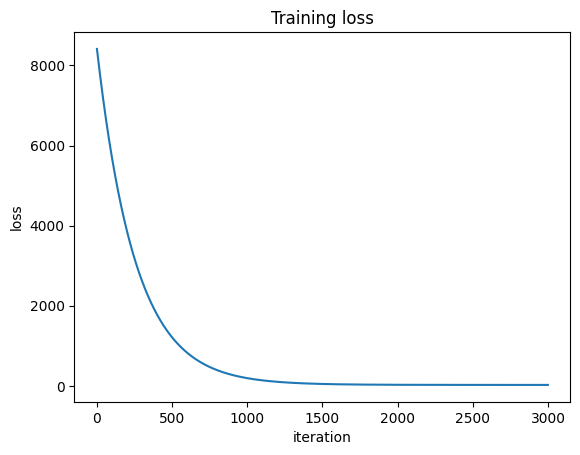

In [ ]:
#loss graph
custom_lin_reg.graph_loss()

In [ ]:
# predict X_test with custom lin reg
y_pred = custom_lin_reg.predict(X_test)

## Sanity check using sklearn

In [ ]:
#comparison with sklearn Linear regression class

from sklearn.linear_model import LinearRegression

sklearn_lin_reg = LinearRegression()
sklearn_lin_reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Sklearn LR results
print(sklearn_lin_reg.coef_)
print(sklearn_lin_reg.intercept_)


[63.67314248 21.89816843 42.97630644 44.60129212  9.45851155]
0.11806659154706367


In [ ]:
# predict X_test with sklearn lin reg class
y_pred_sk = torch.tensor(sklearn_lin_reg.predict(X_test)).float().view(-1, 1)

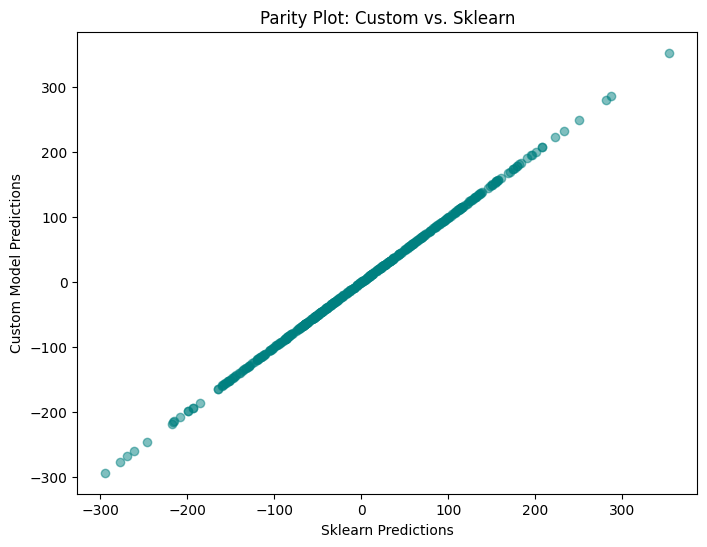

In [ ]:
#compare prediction : sklearn pred vs custom
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_sk, y_pred, alpha=0.5, color='teal')
plt.xlabel("Sklearn Predictions")
plt.ylabel("Custom Model Predictions")
plt.title("Parity Plot: Custom vs. Sklearn")
plt.show()